# Anomaly Detection Using Isolation Forest
The goal in this notebook is to train an Isolation Forest algorithm to flag anomalous data within the data set, and compare the flagged points to those flagged as anomalous within the Auto Encoder method. If both anomaly detection methods converge on a set of points they flag as anomalous, there is an even higher likelihood that these transactions were indeed fraudulent. Goal metrics are % overlap of anomalous events from IF and AE.

# Larger Role in the Fraud Detection Pipeline
Training an Isolation forest algorithm for comparison with the results of the Auto Encoder network establishes a multi-tiered data validation pipeline where data points flagged by both models can be triaged for investigation where a labeled fraud data set will be created. These models sit at stage 1 of the fraud detection pipeline where candidates are generated and then verified and given labels.

In [3]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

# Custom implementation class for sklean Isolation forest
from fraud_detection.models import IsolationForestModel

In [4]:
# Verify working path
!pwd

/mnt/c/Users/Carde/Desktop/git_projects/fraud_detection/notebooks


In [5]:
# Load the data set, un-normalized since IF makes cuts on the variable distribution, no normalization needed.
data_path = "../dataset/credit_card_fraud.h5"
df = pd.read_hdf(data_path, key='fraud_dataset')
df.head()

,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionDate_hour,TransactionWeekNumber,DaysSinceLastPurchase
0,1,0,70,0,81,1,5112.21,2,16,15,572.652083
1,1,0,68,0,141,1,13758.91,3,16,26,495.642361
2,1,2,19,3,56,1,1122.35,1,18,28,482.577083
3,1,2,26,3,25,1,8569.06,3,16,18,548.650694
4,0,2,26,3,198,1,7429.40,0,17,42,384.593750


In [6]:
def fit_model_and_show_fraud_rate(IF_model, dataset) -> list:
    '''
    Shows the fraud rate of a given set of IF scores.
    Score threshold is set at 0, below 0 is flagged as fraud.
    Above 0 is ordinary transactions.
    Args:
        IF_model: A list of IF scores produced by decision_function()
        dataset: A pandas dataset that will be evaluated for fraudulent transactions
    return:
        results: A numpy array of evauation scores for the dataset
        score_samples: A numpy arrat of evaluation scores using 'score_samples' method
    '''
    # Fit the model
    fitted_model = IF_model.fit(dataset)
    results = fitted_model.decision_function(dataset)
    # Gather Scores
    score_samples = fitted_model.score_samples(dataset)
    # Determine anomaly rate
    fraud_rate = sum(results<0)/len(results)
    non_fraud_rate = sum(results>0)/len(results)

    # Quality assurance the proportions sum to 1
    assert fraud_rate+ non_fraud_rate == 1

    # Showing characteristics of scores to user
    print(f"Total Events: {len(results)}")
    print(f"Score Min: {min(results):.3f}, Score Max: {max(results):.3f}")
    print(f"Fraud Rate:     {fraud_rate*100:.2}%")
    print(f"Non Fraud Rate: {non_fraud_rate*100:.2f}%")

    return results, score_samples
    

In [7]:
# Control model, setting contamination level  
control_model = IsolationForestModel(expected_fraud_rate=0.01).get_if_model()
IF_scores, score_samples = fit_model_and_show_fraud_rate(control_model, df)

Total Events: 2512
Score Min: -0.053, Score Max: 0.174
Fraud Rate:     1.0%
Non Fraud Rate: 98.96%


Text(0.5, -0.05, 'Figure 1: Tail in orange indicates statistically fraud candidates.')

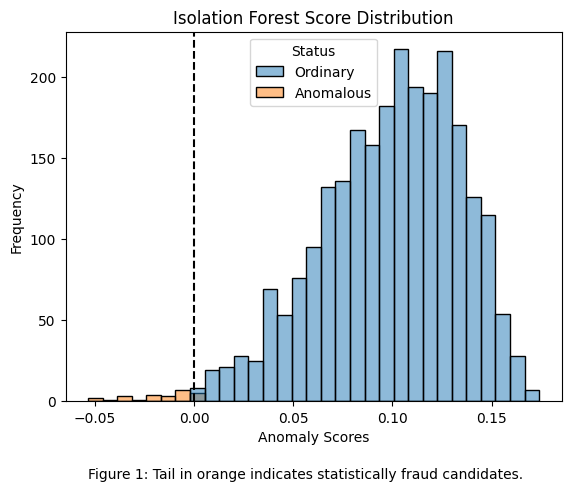

In [8]:
# Plotting the scores from decision_function()
IF_results_as_series = pd.DataFrame(IF_scores, columns=["IF_scores"])
# Adding more descriptive score labels
IF_results_as_series["Status"] = (IF_results_as_series["IF_scores"] < 0).map({
    True: "Anomalous", 
    False: "Ordinary"
})

sns.histplot(data=IF_results_as_series, x="IF_scores", hue="Status")
plt.axvline(0, color="black", linestyle="--")
plt.title("Isolation Forest Score Distribution")
plt.ylabel("Frequency")
plt.xlabel("Anomaly Scores")
plt.figtext(0.5, -0.05, "Figure 1: Tail in orange indicates statistically fraud candidates.", ha="center", fontsize=10)

# Anomaly Score Analysis : Isolation Forest
As observed by the histograms above, we can see that ~1% of the total data set was flagged as anomalous by the Isolation Forest algorithm. We will then gather these anomalous scores and compare them to those identified as anomalous by the Auto Encoder algorithm, and quantify the overlap.

# Anomaly Score Analysis: Auto Encoder

In [9]:
# Load data from VAE and AE for model comparison, do they score the same events as anomalous?
model_scores = pd.read_csv("../dataset/identified_fraud_autoencoder.csv")

In [10]:
model_scores.columns

Index(['Unnamed: 0', 'TransactionType', 'Channel', 'CustomerAge',
       'CustomerOccupation', 'TransactionDuration', 'LoginAttempts',
       'AccountBalance', 'PreviousTransactionDate', 'TransactionDate_hour',
       'TransactionWeekNumber', 'DaysSinceLastPurchase', 'MSE_AE_zscores',
       'MSE_AE', 'MSE_AE_Fraud'],
      dtype='object')

In [11]:
# Evaluate the model with the scores from the stored data set, to ensure they are THE SAME data points
dataset = model_scores[['TransactionType', 'Channel', 'CustomerAge',
       'CustomerOccupation', 'TransactionDuration', 'LoginAttempts',
       'AccountBalance', 'PreviousTransactionDate', 'TransactionDate_hour',
       'TransactionWeekNumber', 'DaysSinceLastPurchase']]

In [12]:
# Evaluating the loaded data set with the trained IF algorithm
IF_scores_loaded_data, _ = fit_model_and_show_fraud_rate(control_model, dataset)

Total Events: 2512
Score Min: -0.053, Score Max: 0.174
Fraud Rate:     1.0%
Non Fraud Rate: 98.96%


In [13]:
# Append the Isolation Forest scores to the loaded data set
# Create and indicator of fraud or no fraud for the IF scores
model_scores["IF_scores"] = IF_scores_loaded_data
model_scores["IF_scores_fraud"] = model_scores["IF_scores"] < 0

In [14]:
model_scores.head()

,Unnamed: 0,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionDate_hour,TransactionWeekNumber,DaysSinceLastPurchase,MSE_AE_zscores,MSE_AE,MSE_AE_Fraud,IF_scores,IF_scores_fraud
0,0,1,0,70,0,81,1,5112.21,2,16,15,572.652083,-0.434677,0.744353,False,0.132657,False
1,1,1,0,68,0,141,1,13758.91,3,16,26,495.642361,0.015130,1.008898,False,0.107279,False
2,2,1,2,19,3,56,1,1122.35,1,18,28,482.577083,0.195357,1.114895,False,0.092712,False
3,3,1,2,26,3,25,1,8569.06,3,16,18,548.650694,-0.347123,0.795847,False,0.092841,False
4,4,0,2,26,3,198,1,7429.40,0,17,42,384.593750,0.514001,1.302300,False,0.036414,False


In [15]:
# Create a column indicating fraud agreement between models
model_scores["AE_IF_agreement"] = (model_scores["MSE_AE_Fraud"]==True) & (model_scores["IF_scores_fraud"]==True)

In [16]:
model_scores.head()

,Unnamed: 0,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionDate_hour,TransactionWeekNumber,DaysSinceLastPurchase,MSE_AE_zscores,MSE_AE,MSE_AE_Fraud,IF_scores,IF_scores_fraud,AE_IF_agreement
0,0,1,0,70,0,81,1,5112.21,2,16,15,572.652083,-0.434677,0.744353,False,0.132657,False,False
1,1,1,0,68,0,141,1,13758.91,3,16,26,495.642361,0.015130,1.008898,False,0.107279,False,False
2,2,1,2,19,3,56,1,1122.35,1,18,28,482.577083,0.195357,1.114895,False,0.092712,False,False
3,3,1,2,26,3,25,1,8569.06,3,16,18,548.650694,-0.347123,0.795847,False,0.092841,False,False
4,4,0,2,26,3,198,1,7429.40,0,17,42,384.593750,0.514001,1.302300,False,0.036414,False,False


In [17]:
# Looks like there are 25 transactions flagged as anomalous by both models
n_agree_fraud = model_scores[model_scores["AE_IF_agreement"]]["AE_IF_agreement"].count()
print(f"Models agree: {n_agree_fraud} transactions are fraud")

Models agree: 25 transactions are fraud


In [18]:
# There are 70 flagged as anomalous by the AE
n_AE_fraud = model_scores[model_scores["MSE_AE_Fraud"]==True]["MSE_AE_Fraud"].count()
print(f"AE Model: {n_AE_fraud} transactions as fraud")
print(f"Percent in agreement with IF: {n_agree_fraud*100/n_AE_fraud:.2f}%")

AE Model: 70 transactions as fraud
Percent in agreement with IF: 35.71%


In [19]:
# There are 26 flagged as anomalous by the IF
n_IF_fraud = model_scores[model_scores["IF_scores_fraud"]==True]["IF_scores_fraud"].count()
print(f"IF Model: {n_IF_fraud} transactions as fraud")
print(f"Percent in agreement with AE: {n_agree_fraud*100/n_IF_fraud:.2f}%")

IF Model: 26 transactions as fraud
Percent in agreement with AE: 96.15%


# Analysis conclusions
Based on the results shown above, we can see that 96% of the fraudulent events flagged by the Isolation Forest Algorithm were also flagged by the Auto Encoder. These points represent high confidence statistical anomalies, candidates for review by a data annotator and worthy of high priority alerts, but not yet confirmed fraudulent transactions. By contrast only ~36% of the events flagged as fraud by the AE are in agreement with the IF, meaning that AE as a much more liberal threshold on what it considers fraudulent activity. 

As a reminder, these fraud determinations for the AE were made using +-2 sigma Z-Scores. Versus an IF contamination rate of 0.01

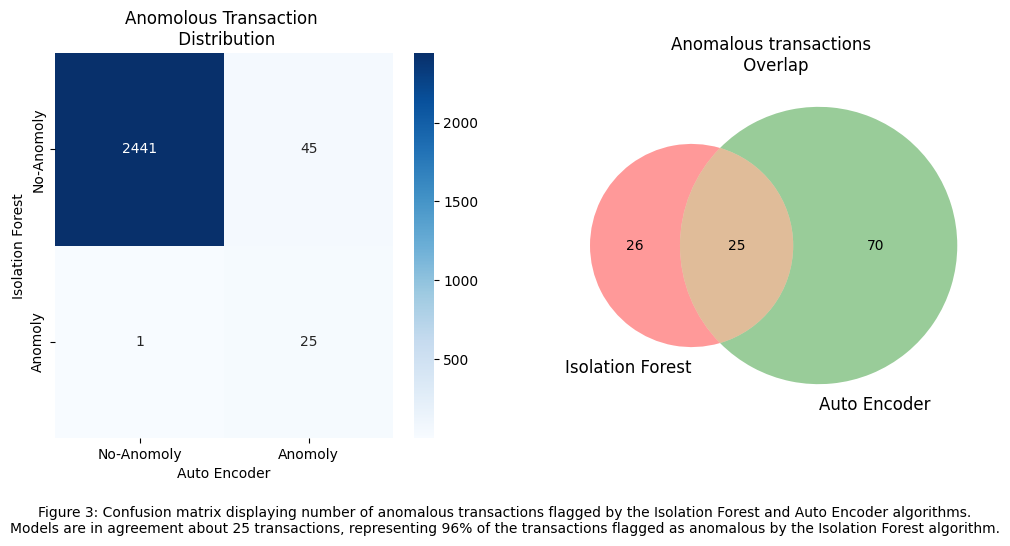

<Figure size 640x480 with 0 Axes>

In [23]:
# Creating a confusion matrix and venn diagram to display overlap in anomalous transactions between models
IF_vs_AE_conf_matrix = confusion_matrix(model_scores["IF_scores_fraud"], model_scores["MSE_AE_Fraud"])
# Create the heat map
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(ax=axes[0], data=IF_vs_AE_conf_matrix, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['No-Anomoly', 'Anomoly'], 
            yticklabels=['No-Anomoly', 'Anomoly'])
axes[0].set_title("Anomolous Transaction \n Distribution")
axes[0].set_xlabel('Auto Encoder')
axes[0].set_ylabel('Isolation Forest')
plt.figtext(0.5, -0.08, 
            "Figure 3: Confusion matrix displaying number of anomalous transactions flagged by the Isolation Forest and Auto Encoder algorithms.\n" 
            "Models are in agreement about 25 transactions, representing 96% of the transactions flagged as anomalous by the Isolation Forest algorithm.",
           ha="center")
axes[1].set_title("Anomalous transactions \n Overlap")
venn2(subsets = (n_IF_fraud, n_AE_fraud, 25), set_labels = ('Isolation Forest', 'Auto Encoder'))
plt.show()

plt.tight_layout()
plt.show()

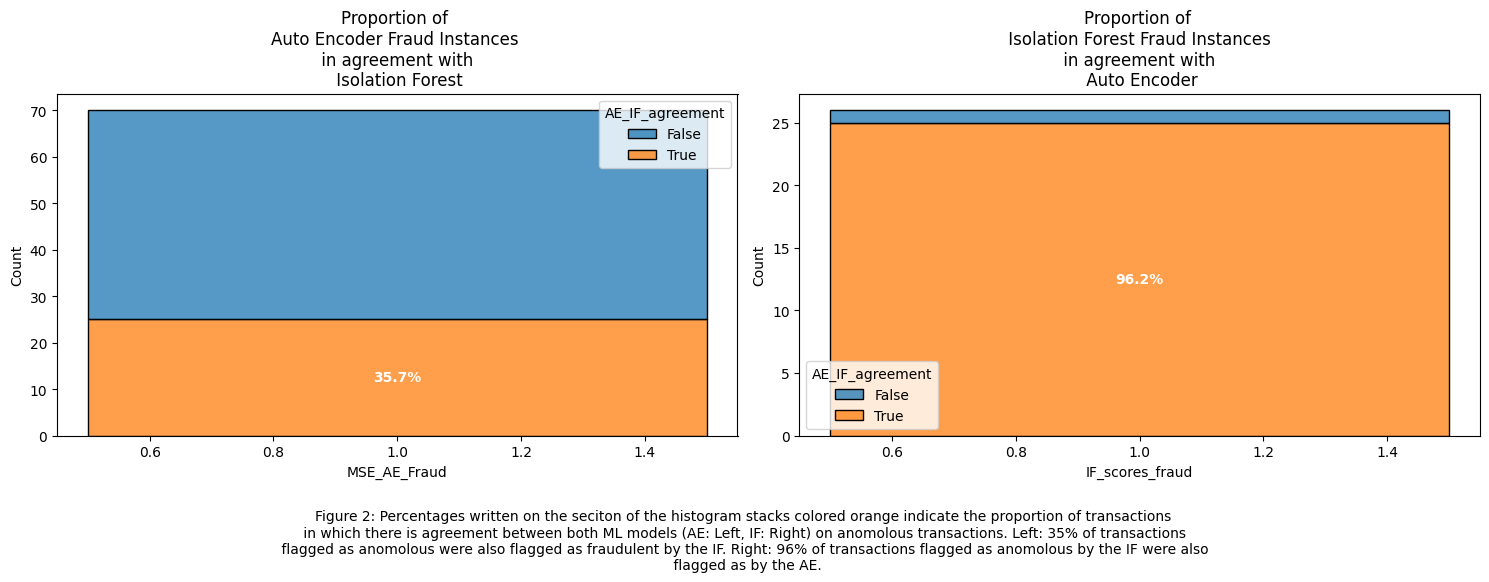

In [24]:
# Making a graphic showing the proportion of agreement between the AE and the IF for fraudulent events

fig, axes = plt.subplots(1,2, figsize=(15,5))
# Extract only AE fraud instances
AE_filtered_data = model_scores[model_scores["MSE_AE_Fraud"]==True][["AE_IF_agreement","MSE_AE_Fraud"]]
sns.histplot(ax=axes[0], 
             data=AE_filtered_data, 
             x="MSE_AE_Fraud", 
             hue=model_scores["AE_IF_agreement"], 
             multiple="stack")
axes[0].set_title("Proportion of \nAuto Encoder Fraud Instances \n in agreement with \n Isolation Forest")

# Extract only IF fraud instances
IF_filtered_data = model_scores[model_scores["IF_scores_fraud"]==True][["AE_IF_agreement","IF_scores_fraud"]]
sns.histplot(ax=axes[1], 
             data=IF_filtered_data, 
             x="IF_scores_fraud", 
             hue=model_scores["AE_IF_agreement"], 
             multiple="stack")
axes[1].set_title("Proportion of \n Isolation Forest Fraud Instances \n in agreement with \n Auto Encoder")

# Adding percentages to the histogram sections representing overlap
for ax in axes:
    # containers[0] =  True (Orange), containers[1] = False (Blue)
    if len(ax.containers) >= 2:
        bottom_bars = ax.containers[0] # The "True" bars
        top_bars = ax.containers[1]    # The "False" bars
        
        for b, t in zip(bottom_bars, top_bars):
            total_height = b.get_height() + t.get_height()
            if total_height > 0:
                percentage = (b.get_height() / total_height) * 100
                
                # Calculate center of the orange (bottom) segment
                label_pos = (b.get_height() / 2)
                
                ax.text(
                    t.get_x() + t.get_width()/2, 
                    label_pos, 
                    f'{percentage:.1f}%', 
                    ha='center', va='center', color='white', fontweight='bold'
                )
# Draw these
plt.figtext(0.5, -0.15, "Figure 2: Percentages written on the seciton of the histogram stacks colored orange indicate the proportion of transactions \n in which there is agreement between both ML models (AE: Left, IF: Right) on anomolous transactions. Left: 35% of transactions \n flagged as anomolous were also flagged as fraudulent by the IF. Right: 96% of transactions flagged as anomolous by the IF were also \n flagged as by the AE.", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# Exporting the data
Lets also export this data set, so that we can make comparisons as to which transactions were flagged as fraud across methods

In [123]:
model_scores.to_csv("./identified_fraud_autoencoder_and_IF.csv")